<a href="https://colab.research.google.com/github/asheldrick-research/ecsm-framework/blob/main/ECSM_Electron_Like_Packet_V40_Model_Competition_Generic_Baselines_FULL_COLAB_RUN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECSM V40 — Model Competition Against Generic Baselines

This is the full Colab evidence notebook for V40. It compares the ECSM/V38 target-response form against generic baselines on two measured targets: sevoflurane and methane. The same train/test split is used for both targets.

## Cell 1 — Imports

In [2]:
import pandas as pd
import numpy as np
import json
import hashlib
import zipfile
from pathlib import Path
from io import StringIO
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

print("V40 model-competition full Colab run")

V40 model-competition full Colab run


## Cell 2 — Load embedded sevoflurane and methane datasets

In [3]:
# Load embedded locked sevoflurane dataset and rebuild locked methane dataset.

SEVO_CSV = 'dataset_id,source_reference,beam_energy_keV,beam_energy_eV,theta_deg,q_transfer_keV,observable,sigma,normalisation_reference,notes,target\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.05,50,25,3.094477817583581,3.6,1.1,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.05,50,30,3.700384505707712,3.07,0.93,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.05,50,35,4.299247301609123,2.17,0.66,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.05,50,40,4.889926235918677,1.89,0.43,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.05,50,45,5.471296917712922,1.77,0.4,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.05,50,50,6.042252674856112,1.57,0.36,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.05,50,55,6.601706660613521,1.31,0.3,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.05,50,60,7.148593922525975,1.01,0.23,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.05,50,65,7.681873429607385,0.82,0.18,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.05,50,70,8.20053005400639,0.68,0.15,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.05,50,75,8.703576503359937,0.55,0.13,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.05,50,80,9.190055200160389,0.47,0.11,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.05,50,85,9.65904010455874,0.38,0.086,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.05,50,90,10.109638477134116,0.339,0.077,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.05,50,95,10.54099257827398,0.327,0.074,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.05,50,100,10.952281300930244,0.347,0.079,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.05,50,105,11.342721733643211,0.396,0.09,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.05,50,110,11.71157065085803,0.48,0.11,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.05,50,115,12.05812592769678,0.59,0.13,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.05,50,120,12.381727876493084,0.71,0.16,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.05,50,125,12.681760502545076,0.85,0.19,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.1,100,25,4.376359542949291,2.55,0.76,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.1,100,30,5.233261958484935,1.98,0.59,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.1,100,35,6.080202562443438,1.64,0.49,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.1,100,40,6.915569155248208,1.14,0.34,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.1,100,45,7.737771569110707,0.78,0.23,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.1,100,50,8.545244695005218,0.61,0.14,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.1,100,55,9.336451461942827,0.49,0.11,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.1,100,60,10.109885762873416,0.428,0.098,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.1,100,65,10.864075321646038,0.369,0.084,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.1,100,70,11.597584495570224,0.307,0.07,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.1,100,75,12.309017008243485,0.243,0.056,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.1,100,80,12.997018607442758,0.203,0.047,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.1,100,85,13.66027964302052,0.165,0.038,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.1,100,90,14.29753755989825,0.157,0.036,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.1,100,95,14.907579301411806,0.154,0.035,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.1,100,100,15.489243618433704,0.175,0.04,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.1,100,105,16.041423279876856,0.188,0.043,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.1,100,110,16.563067180371867,0.225,0.051,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.1,100,115,17.053182341105842,0.265,0.061,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.1,100,120,17.510835800013997,0.311,0.071,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.1,100,125,17.935156387725986,0.367,0.084,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.15,150,25,5.36005500502928,1.5,0.39,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.15,150,30,6.409567513345311,1.25,0.32,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.15,150,35,7.446879045603688,0.82,0.21,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.15,150,40,8.470015020345821,0.69,0.14,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.15,150,45,9.477027840092545,0.55,0.11,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.15,150,50,10.4660005987066,0.476,0.094,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.15,150,55,11.435050730332431,0.386,0.077,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.15,150,60,12.382333592967276,0.289,0.057,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.15,150,65,13.30604597984208,0.211,0.042,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.15,150,70,14.20442955192803,0.155,0.031,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.15,150,75,15.075774185034891,0.126,0.025,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.15,150,80,15.918421225129547,0.117,0.023,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.15,150,85,16.730766645678255,0.127,0.025,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.15,150,90,17.511264101002297,0.125,0.025,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.15,150,95,18.2584278698349,0.129,0.026,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.15,150,100,18.970835683476064,0.128,0.025,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.15,150,105,19.647131433161924,0.13,0.026,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.15,150,110,20.286027751494807,0.146,0.029,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.15,150,115,20.886308463020278,0.161,0.032,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.15,150,120,21.44683089928621,0.179,0.035,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.15,150,125,21.966528073977177,0.193,0.038,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.2,200,25,6.189409776937151,2.25,0.74,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.2,200,30,7.401312075307985,1.44,0.48,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.2,200,35,8.599125555480393,1.01,0.33,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.2,200,40,9.780570111415596,0.8,0.26,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.2,200,45,10.943396796252456,0.71,0.24,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.2,200,50,12.085392103305637,0.61,0.16,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.2,200,55,13.204382179601389,0.41,0.11,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.2,200,60,14.298236963930249,0.27,0.071,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.2,200,65,15.364874241539606,0.214,0.057,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.2,200,70,16.402263607747823,0.194,0.051,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.2,200,75,17.40843033293498,0.195,0.051,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.2,200,80,18.38145912155289,0.179,0.047,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.2,200,85,19.319497757999088,0.165,0.044,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.2,200,90,20.22076063241446,0.16,0.043,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.2,200,95,21.083532139693137,0.162,0.044,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.2,200,100,21.906169945234268,0.167,0.044,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.2,200,105,22.687108111219345,0.16,0.042,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.2,200,110,23.42486007746378,0.16,0.042,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.2,200,115,24.118021491168754,0.165,0.044,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.2,200,120,24.76527288018656,0.173,0.046,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.2,200,125,25.365382164710837,0.17,0.045,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.25,250,25,6.920139741282727,1.82,0.56,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.25,250,30,8.275120839602895,1.2,0.37,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.25,250,35,9.614349775077756,0.99,0.3,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.25,250,40,10.93527724931184,0.84,0.26,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.25,250,45,12.23538880178133,0.67,0.16,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.25,250,50,13.51220959625259,0.43,0.1,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.25,250,55,14.763309131773594,0.282,0.067,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.25,250,60,15.986305869270629,0.223,0.053,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.25,250,65,17.178871764943285,0.22,0.052,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.25,250,70,18.33873670182812,0.189,0.045,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.25,250,75,19.46369281109537,0.162,0.038,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.25,250,80,20.551598674852723,0.15,0.036,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.25,250,85,21.600383402455986,0.139,0.033,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.25,250,90,22.608050572567134,0.127,0.03,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.25,250,95,23.572682033455813,0.117,0.028,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.25,250,100,24.49244155431014,0.109,0.026,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.25,250,105,25.365578320606463,0.111,0.027,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.25,250,110,26.190430266884288,0.118,0.028,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.25,250,115,26.965427240582358,0.113,0.027,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.25,250,120,27.68909399091328,0.116,0.028,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.25,250,125,28.360052977087275,0.122,0.029,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.3,300,25,7.580818663775409,1.53,0.45,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.3,300,30,9.065162388502625,1.12,0.33,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.3,300,35,10.532250061393178,0.96,0.28,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.3,300,40,11.979288997677909,0.72,0.21,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.3,300,45,13.40352467649728,0.43,0.13,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.3,300,50,14.8022459842884,0.304,0.066,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.3,300,55,16.172790375543762,0.235,0.051,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.3,300,60,17.51254894111796,0.202,0.044,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.3,300,65,18.818971374434533,0.18,0.039,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.3,300,70,20.08957082613945,0.16,0.035,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.3,300,75,21.32192863796026,0.141,0.031,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.3,300,80,22.513698946759497,0.122,0.027,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.3,300,85,23.66261315001859,0.107,0.024,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.3,300,90,24.76648422425161,0.095,0.021,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.3,300,95,25.82321088812882,0.096,0.021,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.3,300,100,26.83078160238512,0.091,0.02,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.3,300,105,27.78727839889934,0.09,0.021,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.3,300,110,28.6908805316556,0.093,0.02,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.3,300,115,29.5398679426368,0.089,0.02,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.3,300,120,30.33262453605285,0.088,0.02,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.3,300,125,31.067641254670857,0.085,0.019,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1,sevoflurane\n'
sevo_df = pd.read_csv(StringIO(SEVO_CSV))

energies = [50, 100, 150, 200, 250, 300]
methane_table = {25: ['1.96(60)', '0.98(30)', '0.45(14)', '0.39(12)', '0.325(93)', '0.277(78)'], 30: ['1.30(40)', '0.61(19)', '0.277(87)', '0.246(76)', '0.200(57)', '0.181(51)'], 35: ['0.73(22)', '0.40(12)', '0.194(61)', '0.175(54)', '0.136(39)', '0.128(36)'], 40: ['0.50(12)', '0.288(89)', '0.162(51)', '0.132(41)', '0.106(22)', '0.100(20)'], 45: ['0.384(88)', '0.230(55)', '0.127(31)', '0.105(25)', '0.072(15)', '0.058(12)'], 50: ['0.302(70)', '0.174(41)', '0.090(22)', '0.072(17)', '0.053(11)', '0.0423(85)'], 55: ['0.249(57)', '0.128(30)', '0.061(15)', '0.055(13)', '0.0413(85)', '0.0347(70)'], 60: ['0.206(47)', '0.091(22)', '0.047(12)', '0.044(10)', '0.0324(67)', '0.0264(53)'], 65: ['0.173(40)', '0.068(16)', '0.0398(99)', '0.0362(88)', '0.0271(57)', '0.0214(43)'], 70: ['0.144(33)', '0.055(13)', '0.0340(84)', '0.0306(74)', '0.0229(48)', '0.0186(38)'], 75: ['0.111(26)', '0.0451(11)', '0.0305(76)', '0.0291(71)', '0.0211(44)', '0.0154(31)'], 80: ['0.092(21)', '0.0409(98)', '0.0283(70)', '0.0252(61)', '0.0181(38)', '0.0120(25)'], 85: ['0.072(17)', '0.0381(93)', '0.0284(71)', '0.0244(59)', '0.0145(31)', '0.0107(22)'], 90: ['0.067(16)', '0.0403(96)', '0.0263(66)', '0.0212(52)', '0.0121(26)', '0.0096(20)'], 95: ['0.062(14)', '0.043(10)', '0.0274(68)', '0.0195(48)', '0.0120(26)', '0.0088(18)'], 100: ['0.061(14)', '0.047(11)', '0.0256(64)', '0.0183(45)', '0.0118(26)', '0.0088(18)'], 105: ['0.066(15)', '0.049(12)', '0.0252(63)', '0.0185(45)', '0.0106(23)', '0.0085(18)'], 110: ['0.078(18)', '0.051(12)', '0.0250(62)', '0.0160(39)', '0.0099(22)', '0.0078(16)'], 115: ['0.087(20)', '0.057(14)', '0.0250(62)', '0.0154(38)', '0.0094(21)', '0.0078(16)'], 120: ['0.102(24)', '0.061(15)', '0.0260(65)', '0.0155(38)', '0.0092(20)', '0.0073(15)'], 125: ['0.118(27)', '0.063(15)', '0.0264(66)', '0.0141(35)', '0.0092(20)', '0.0075(16)']}

def parse_value_uncertainty(cell):
    value_text, sigma_text = cell.split("(")
    sigma_text = sigma_text.rstrip(")")
    value = float(value_text)
    decimals = len(value_text.split(".")[1]) if "." in value_text else 0
    sigma = int(sigma_text) * 10**(-decimals)
    return value, sigma

m_e_keV = 510.9989506917532

methane_rows = []
for theta_deg, values in methane_table.items():
    for energy_eV, cell in zip(energies, values):
        observable, sigma = parse_value_uncertainty(cell)
        beam_energy_keV = energy_eV / 1000.0
        p_keV = np.sqrt(beam_energy_keV*(beam_energy_keV + 2*m_e_keV))
        q_transfer_keV = 2*p_keV*np.sin(np.deg2rad(theta_deg)/2.0)
        methane_rows.append({
            "dataset_id": "Vukalovic2021_methane_elastic_DCS_Table2_measured_only",
            "source_reference": "Vukalovic et al., IJMS 2021, 22, 647, Table 2, DOI:10.3390/ijms22020647",
            "beam_energy_keV": beam_energy_keV,
            "beam_energy_eV": energy_eV,
            "theta_deg": theta_deg,
            "q_transfer_keV": q_transfer_keV,
            "observable": observable,
            "sigma": sigma,
            "normalisation_reference": "90 degree bin",
            "notes": "measured 25-125 deg only; DCS unit 1e-20 m^2 sr^-1",
            "target": "methane",
        })

methane_df = pd.DataFrame(methane_rows).sort_values(["beam_energy_eV","theta_deg"]).reset_index(drop=True)
sevo_df["target"] = "sevoflurane"

print("Sevoflurane rows:", len(sevo_df))
print("Methane rows:", len(methane_df))
display(sevo_df.head())
display(methane_df.head())

Sevoflurane rows: 126
Methane rows: 126


,dataset_id,source_reference,beam_energy_keV,beam_energy_eV,theta_deg,q_transfer_keV,observable,sigma,normalisation_reference,notes,target
0,Vukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, ...",0.05,50,25,3.094478,3.60,1.10,raw absolute DCS from Table 1; shape normalisa...,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflu...,sevoflurane
1,Vukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, ...",0.05,50,30,3.700385,3.07,0.93,raw absolute DCS from Table 1; shape normalisa...,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflu...,sevoflurane
2,Vukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, ...",0.05,50,35,4.299247,2.17,0.66,raw absolute DCS from Table 1; shape normalisa...,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflu...,sevoflurane
3,Vukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, ...",0.05,50,40,4.889926,1.89,0.43,raw absolute DCS from Table 1; shape normalisa...,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflu...,sevoflurane
4,Vukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, ...",0.05,50,45,5.471297,1.77,0.40,raw absolute DCS from Table 1; shape normalisa...,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflu...,sevoflurane


,dataset_id,source_reference,beam_energy_keV,beam_energy_eV,theta_deg,q_transfer_keV,observable,sigma,normalisation_reference,notes,target
0,Vukalovic2021_methane_elastic_DCS_Table2_measu...,"Vukalovic et al., IJMS 2021, 22, 647, Table 2,...",0.05,50,25,3.094478,1.960,0.600,90 degree bin,measured 25-125 deg only; DCS unit 1e-20 m^2 s...,methane
1,Vukalovic2021_methane_elastic_DCS_Table2_measu...,"Vukalovic et al., IJMS 2021, 22, 647, Table 2,...",0.05,50,30,3.700385,1.300,0.400,90 degree bin,measured 25-125 deg only; DCS unit 1e-20 m^2 s...,methane
2,Vukalovic2021_methane_elastic_DCS_Table2_measu...,"Vukalovic et al., IJMS 2021, 22, 647, Table 2,...",0.05,50,35,4.299247,0.730,0.220,90 degree bin,measured 25-125 deg only; DCS unit 1e-20 m^2 s...,methane
3,Vukalovic2021_methane_elastic_DCS_Table2_measu...,"Vukalovic et al., IJMS 2021, 22, 647, Table 2,...",0.05,50,40,4.889926,0.500,0.120,90 degree bin,measured 25-125 deg only; DCS unit 1e-20 m^2 s...,methane
4,Vukalovic2021_methane_elastic_DCS_Table2_measu...,"Vukalovic et al., IJMS 2021, 22, 647, Table 2,...",0.05,50,45,5.471297,0.384,0.088,90 degree bin,measured 25-125 deg only; DCS unit 1e-20 m^2 s...,methane


## Cell 3 — Frozen ECSM constants and train/test split

In [4]:
# Frozen ECSM constants and train/test split.

q_eff = -0.9993035720499918
E_rest_keV = 514.0698767738036
alpha_fs = 0.0072973525692838015
k_response_keV = 5140.698767738036
r_rms_response_fm = 38.385244752791856
Pi_ecsm_plateau_locked = 0.007146727844882419

REF_THETA = 90.0
TRAIN_E = [50, 150, 250]
TEST_E = [100, 200, 300]

print("Train energies:", TRAIN_E)
print("Held-out test energies:", TEST_E)

Train energies: [50, 150, 250]
Held-out test energies: [100, 200, 300]


## Cell 4 — Compute frozen ECSM reference and required response

In [5]:
# Compute frozen bare ECSM reference and required target response.

def compute_base(df):
    work = df.copy()
    theta = np.deg2rad(work["theta_deg"].astype(float))
    T = work["beam_energy_keV"].astype(float)
    p = np.sqrt(T*(T+2*m_e_keV))
    beta = p/(T+m_e_keV)
    sin_half = np.sin(theta/2.0)

    spin = np.clip(1-beta**2*sin_half**2, 1e-300, None)
    F = np.exp(-(work["q_transfer_keV"].astype(float)/k_response_keV)**2/6.0)
    running = 1/(1+Pi_ecsm_plateau_locked*(work["q_transfer_keV"].astype(float)**2/(work["q_transfer_keV"].astype(float)**2+k_response_keV**2)))

    work["p_keV"] = p
    work["beta_rel"] = beta
    work["ecsm_shape_raw"] = spin/np.clip(sin_half,1e-300,None)**4 * F**2 * running**2

    pieces = []
    for E, d in work.groupby("beam_energy_eV", sort=True):
        d = d.copy()
        ref = d[np.isclose(d["theta_deg"].astype(float), REF_THETA)]
        if len(ref) != 1:
            raise ValueError(f"Missing unique 90 degree bin for {E}")
        ref_meas = float(ref["observable"].iloc[0])
        ref_ecsm = float(ref["ecsm_shape_raw"].iloc[0])

        d["measured_shape_norm"] = d["observable"].astype(float)/ref_meas
        d["ecsm_shape_norm"] = d["ecsm_shape_raw"]/ref_ecsm
        d["required_target_response"] = d["measured_shape_norm"]/np.maximum(d["ecsm_shape_norm"],1e-300)
        pieces.append(d)

    diag = pd.concat(pieces, ignore_index=True)
    diag["log_required_target_response"] = np.log(np.maximum(diag["required_target_response"],1e-300))
    diag["split"] = np.where(diag["beam_energy_eV"].isin(TRAIN_E), "train", "test")
    return diag

## Cell 5 — Define model features

In [6]:
# Define ECSM response and generic baseline model features.

def per_energy_feature(data, fun):
    frames = []
    for E, d in data.groupby("beam_energy_eV", sort=False):
        q = d["q_transfer_keV"].astype(float).to_numpy()
        theta = d["theta_deg"].astype(float).to_numpy()
        q90 = float(d.loc[np.isclose(d["theta_deg"].astype(float), REF_THETA), "q_transfer_keV"].iloc[0])
        payload = fun(q, theta, q90)
        frames.append(pd.DataFrame({"idx": d.index, **payload}))
    out = pd.concat(frames).set_index("idx").sort_index()
    return out.loc[data.index].to_numpy()

def model_features(data, model, params):
    if model == "ecsm_screen_polar":
        qs = params["q_s"]
        qp = params["q_p"]
        return per_energy_feature(data, lambda q, theta, q90: {
            "screen": np.log1p((q/qs)**2) - np.log1p((q90/qs)**2),
            "polar": q*q/(q*q+qp*qp) - q90*q90/(q90*q90+qp*qp),
        })

    if model == "screen1":
        qs = params["q_s"]
        return per_energy_feature(data, lambda q, theta, q90: {
            "screen": np.log1p((q/qs)**2) - np.log1p((q90/qs)**2),
        })

    if model == "polar1":
        qp = params["q_p"]
        return per_energy_feature(data, lambda q, theta, q90: {
            "polar": q*q/(q*q+qp*qp) - q90*q90/(q90*q90+qp*qp),
        })

    if model == "logq_poly2":
        return per_energy_feature(data, lambda q, theta, q90: {
            "x1": np.log(q/q90),
            "x2": np.log(q/q90)**2,
        })

    if model == "theta_poly2":
        return per_energy_feature(data, lambda q, theta, q90: {
            "x1": (theta-90.0)/90.0,
            "x2": ((theta-90.0)/90.0)**2,
        })

    if model == "logq_poly4":
        return per_energy_feature(data, lambda q, theta, q90: {
            "x1": np.log(q/q90),
            "x2": np.log(q/q90)**2,
            "x3": np.log(q/q90)**3,
            "x4": np.log(q/q90)**4,
        })

    if model == "theta_poly4":
        return per_energy_feature(data, lambda q, theta, q90: {
            "x1": (theta-90.0)/90.0,
            "x2": ((theta-90.0)/90.0)**2,
            "x3": ((theta-90.0)/90.0)**3,
            "x4": ((theta-90.0)/90.0)**4,
        })

    raise ValueError(model)

## Cell 6 — Fit and predict models

In [7]:
# Fit and predict each model under the same train/test rules.

def fit_model(diag, model):
    train_mask = diag["beam_energy_eV"].isin(TRAIN_E)
    y = diag.loc[train_mask, "log_required_target_response"].to_numpy()
    q = diag["q_transfer_keV"].to_numpy()

    if model == "bare":
        return {"params": {}, "coef": np.array([]), "n_params": 0, "train_log_mse": np.nan}

    if model == "ecsm_screen_polar":
        grid = np.geomspace(max(0.25*q.min(),0.1), 4*q.max(), 41)
        best = None
        for qs in grid:
            for qp in grid:
                X = model_features(diag.loc[train_mask], model, {"q_s":qs,"q_p":qp})
                coef, *_ = np.linalg.lstsq(X, y, rcond=None)
                mse = float(np.mean((y-X@coef)**2))
                if best is None or mse < best["train_log_mse"]:
                    best = {"params":{"q_s":float(qs),"q_p":float(qp)}, "coef":coef, "n_params":4, "train_log_mse":mse}
        return best

    if model == "screen1":
        grid = np.geomspace(max(0.25*q.min(),0.1), 4*q.max(), 81)
        best = None
        for qs in grid:
            X = model_features(diag.loc[train_mask], model, {"q_s":qs})
            coef, *_ = np.linalg.lstsq(X, y, rcond=None)
            mse = float(np.mean((y-X@coef)**2))
            if best is None or mse < best["train_log_mse"]:
                best = {"params":{"q_s":float(qs)}, "coef":coef, "n_params":2, "train_log_mse":mse}
        return best

    if model == "polar1":
        grid = np.geomspace(max(0.25*q.min(),0.1), 4*q.max(), 81)
        best = None
        for qp in grid:
            X = model_features(diag.loc[train_mask], model, {"q_p":qp})
            coef, *_ = np.linalg.lstsq(X, y, rcond=None)
            mse = float(np.mean((y-X@coef)**2))
            if best is None or mse < best["train_log_mse"]:
                best = {"params":{"q_p":float(qp)}, "coef":coef, "n_params":2, "train_log_mse":mse}
        return best

    X = model_features(diag.loc[train_mask], model, {})
    coef, *_ = np.linalg.lstsq(X, y, rcond=None)
    mse = float(np.mean((y-X@coef)**2))
    return {"params":{}, "coef":coef, "n_params":len(coef), "train_log_mse":mse}

def predict_model(diag, model, fit):
    if model == "bare":
        R = np.ones(len(diag))
        pred = diag["ecsm_shape_norm"].to_numpy()
    else:
        X = model_features(diag, model, fit["params"])
        R = np.exp(X @ fit["coef"])
        pred = diag["ecsm_shape_norm"].to_numpy() * R

    resid = np.abs(pred - diag["measured_shape_norm"].to_numpy())/np.maximum(np.abs(diag["measured_shape_norm"].to_numpy()),1e-300)
    return R, pred, resid

## Cell 7 — Run V40 competition

In [8]:
# Run V40 model competition.

models = ['bare', 'ecsm_screen_polar', 'screen1', 'polar1', 'logq_poly2', 'theta_poly2', 'logq_poly4', 'theta_poly4']
model_labels = {'bare': 'Bare ECSM', 'ecsm_screen_polar': 'ECSM response form', 'screen1': 'Screen-only', 'polar1': 'Polar-only', 'logq_poly2': 'Generic log-q poly2', 'theta_poly2': 'Generic theta poly2', 'logq_poly4': 'Generic log-q poly4', 'theta_poly4': 'Generic theta poly4'}

diagnostics = []
rows = []
fits_store = {}

for target, target_df in [("sevoflurane", sevo_df), ("methane", methane_df)]:
    diag = compute_base(target_df)
    diag["target"] = target
    fits_store[target] = {}

    for model in models:
        fit = fit_model(diag, model)
        fits_store[target][model] = {
            "params": fit["params"],
            "coef": [float(x) for x in fit["coef"]],
            "n_params": int(fit["n_params"]),
            "train_log_mse": None if pd.isna(fit["train_log_mse"]) else float(fit["train_log_mse"]),
        }

        R, pred, resid = predict_model(diag, model, fit)
        diag[f"{model}_R_pred"] = R
        diag[f"{model}_pred_shape"] = pred
        diag[f"{model}_relative_residual"] = resid

        for split, mask in [("train", diag["beam_energy_eV"].isin(TRAIN_E)), ("test", diag["beam_energy_eV"].isin(TEST_E))]:
            s = pd.Series(resid[mask.to_numpy()])
            rows.append({
                "target": target,
                "model": model,
                "model_label": model_labels[model],
                "split": split,
                "n_params": int(fit["n_params"]),
                "mean": float(s.mean()),
                "median": float(s.median()),
                "max": float(s.max()),
                "train_log_mse": None if pd.isna(fit["train_log_mse"]) else float(fit["train_log_mse"]),
                "params": json.dumps(fit["params"]),
                "coef": json.dumps([float(x) for x in fit["coef"]]),
            })

    diagnostics.append(diag)

diag_all = pd.concat(diagnostics, ignore_index=True)
results_df = pd.DataFrame(rows)
test_results = results_df[results_df["split"]=="test"].copy()
aggregate_results = results_df.groupby(["model","model_label","split","n_params"], as_index=False)[["mean","median","max"]].mean()

display(test_results.sort_values(["target","mean"]))

,target,model,model_label,split,n_params,mean,median,max,train_log_mse,params,coef
25,methane,logq_poly2,Generic log-q poly2,test,2,0.149453,0.089787,0.666584,0.075079,{},"[2.1365789620359594, 0.8679783348729126]"
29,methane,logq_poly4,Generic log-q poly4,test,4,0.156778,0.141759,0.644599,0.036057,{},"[2.587873347346726, 5.962133798746106, 8.13104..."
31,methane,theta_poly4,Generic theta poly4,test,4,0.158905,0.142606,0.710282,0.035708,{},"[1.8244093642409973, 2.0182954531360635, 1.465..."
27,methane,theta_poly2,Generic theta poly2,test,2,0.160359,0.120232,0.737423,0.051820,{},"[2.076908565178271, 0.4384504991976213]"
21,methane,screen1,Screen-only,test,2,0.163334,0.130572,0.630824,0.088380,"{""q_s"": 4.031119492355752}",[0.8380239821016504]
23,methane,polar1,Polar-only,test,2,0.170896,0.141333,0.629838,0.089364,"{""q_p"": 12.639790398730963}",[3.3674874286878373]
19,methane,ecsm_screen_polar,ECSM response form,test,4,0.173882,0.143019,0.641734,0.082747,"{""q_s"": 23.848989564693145, ""q_p"": 39.63273766...","[114.94035632026784, -290.0493137862326]"
17,methane,bare,Bare ECSM,test,0,0.870439,0.521975,5.194701,NaN,{},[]
15,sevoflurane,theta_poly4,Generic theta poly4,test,4,0.161986,0.141035,0.757894,0.033378,{},"[2.415632964672289, 3.5401439044098, 0.9284175..."
13,sevoflurane,logq_poly4,Generic log-q poly4,test,4,0.162059,0.132214,0.731354,0.033283,{},"[3.298934295828297, 8.632252241121932, 12.0612..."


## Cell 8 — Verdict and criteria

In [9]:
# V40 verdict and criteria.

best_by_target = test_results.loc[test_results.groupby("target")["mean"].idxmin()].reset_index(drop=True)
ecsm_by_target = test_results[test_results["model"]=="ecsm_screen_polar"].copy()

comparison_rows = []
for target in sorted(test_results["target"].unique()):
    best = best_by_target[best_by_target["target"]==target].iloc[0]
    ecsm = ecsm_by_target[ecsm_by_target["target"]==target].iloc[0]

    comparison_rows.append({
        "target": target,
        "best_model": best["model_label"],
        "best_mean": float(best["mean"]),
        "ecsm_mean": float(ecsm["mean"]),
        "ecsm_to_best_ratio": float(ecsm["mean"]/best["mean"]),
        "ecsm_within_20_percent_of_best": bool(ecsm["mean"] <= 1.2*best["mean"]),
        "ecsm_is_best": bool(ecsm["model"] == best["model"]),
    })

best_comparison_df = pd.DataFrame(comparison_rows)

strong_pass = bool(best_comparison_df["ecsm_is_best"].all())
weak_pass = bool(best_comparison_df["ecsm_within_20_percent_of_best"].all())

if strong_pass:
    final_label = "PASS_STRONG_ECSM_RESPONSE_BEST_MODEL"
elif weak_pass:
    final_label = "PASS_WEAK_ECSM_RESPONSE_COMPETITIVE_NOT_BEST"
else:
    final_label = "FAIL_ECSM_RESPONSE_OUTCOMPETED_BY_GENERIC_BASELINES"

criteria_df = pd.DataFrame([
    ("two measured molecular targets locked", 2, True),
    ("same train/test split used for both targets", str({"train":TRAIN_E,"test":TEST_E}), True),
    ("frozen ECSM packet unchanged", 0, True),
    ("bare ECSM included", 1, True),
    ("ECSM response form included", 1, True),
    ("generic lower-parameter baselines included", 4, True),
    ("generic equal-parameter baselines included", 2, True),
    ("ECSM response passes residual threshold on sevoflurane", float(ecsm_by_target[ecsm_by_target.target=="sevoflurane"]["mean"].iloc[0]), bool(ecsm_by_target[ecsm_by_target.target=="sevoflurane"]["mean"].iloc[0] <= 0.25)),
    ("ECSM response passes residual threshold on methane", float(ecsm_by_target[ecsm_by_target.target=="methane"]["mean"].iloc[0]), bool(ecsm_by_target[ecsm_by_target.target=="methane"]["mean"].iloc[0] <= 0.25)),
    ("ECSM response best on all targets", int(strong_pass), strong_pass),
    ("ECSM response within 20 percent of best on all targets", int(weak_pass), weak_pass),
    ("generic baselines allowed to win", 1, True),
    ("no full molecular QED claim", 1, True),
], columns=["criterion","value","pass"])

run_summary = {
    "run_label": "V40_model_competition_two_target_measured_scattering",
    "final_label": final_label,
    "n_pass": int(criteria_df["pass"].sum()),
    "n_criteria": int(len(criteria_df)),
    "targets": ["sevoflurane","methane"],
    "train_energies_eV": TRAIN_E,
    "test_energies_eV": TEST_E,
    "models_compared": model_labels,
    "best_by_target": best_by_target[["target","model_label","n_params","mean","median","max"]].to_dict(orient="records"),
    "ecsm_by_target": ecsm_by_target[["target","model_label","n_params","mean","median","max"]].to_dict(orient="records"),
    "best_comparison": best_comparison_df.to_dict(orient="records"),
    "aggregate_test_ranking": aggregate_results[aggregate_results.split=="test"].sort_values("mean")[["model_label","n_params","mean","median","max"]].to_dict(orient="records"),
    "claim_boundary": "V40 is a model-competition audit. The ECSM response form passes held-out residual thresholds and is competitive within 20 percent of the best baseline on both targets, but generic polynomial baselines achieve the lowest held-out residuals. This is a weak/competitive pass, not a strong model-selection win.",
}

print(json.dumps(run_summary, indent=2))
display(best_comparison_df)
display(criteria_df)
display(aggregate_results[aggregate_results.split=="test"].sort_values("mean"))

{
  "run_label": "V40_model_competition_two_target_measured_scattering",
  "final_label": "PASS_WEAK_ECSM_RESPONSE_COMPETITIVE_NOT_BEST",
  "n_pass": 12,
  "n_criteria": 13,
  "targets": [
    "sevoflurane",
    "methane"
  ],
  "train_energies_eV": [
    50,
    150,
    250
  ],
  "test_energies_eV": [
    100,
    200,
    300
  ],
  "models_compared": {
    "bare": "Bare ECSM",
    "ecsm_screen_polar": "ECSM response form",
    "screen1": "Screen-only",
    "polar1": "Polar-only",
    "logq_poly2": "Generic log-q poly2",
    "theta_poly2": "Generic theta poly2",
    "logq_poly4": "Generic log-q poly4",
    "theta_poly4": "Generic theta poly4"
  },
  "best_by_target": [
    {
      "target": "methane",
      "model_label": "Generic log-q poly2",
      "n_params": 2,
      "mean": 0.14945296824486015,
      "median": 0.08978676041197407,
      "max": 0.6665839829339728
    },
    {
      "target": "sevoflurane",
      "model_label": "Generic theta poly4",
      "n_params": 4,
      "

,target,best_model,best_mean,ecsm_mean,ecsm_to_best_ratio,ecsm_within_20_percent_of_best,ecsm_is_best
0,methane,Generic log-q poly2,0.149453,0.173882,1.163455,True,False
1,sevoflurane,Generic theta poly4,0.161986,0.185038,1.142311,True,False


,criterion,value,pass
0,two measured molecular targets locked,2,True
1,same train/test split used for both targets,"{'train': [50, 150, 250], 'test': [100, 200, 3...",True
2,frozen ECSM packet unchanged,0,True
3,bare ECSM included,1,True
4,ECSM response form included,1,True
5,generic lower-parameter baselines included,4,True
6,generic equal-parameter baselines included,2,True
7,ECSM response passes residual threshold on sev...,0.185038,True
8,ECSM response passes residual threshold on met...,0.173882,True
9,ECSM response best on all targets,0,False


,model,model_label,split,n_params,mean,median,max
6,logq_poly4,Generic log-q poly4,test,4,0.159418,0.136987,0.687976
14,theta_poly4,Generic theta poly4,test,4,0.160446,0.141820,0.734088
12,theta_poly2,Generic theta poly2,test,2,0.168769,0.140057,0.638005
4,logq_poly2,Generic log-q poly2,test,2,0.173323,0.124208,0.672169
2,ecsm_screen_polar,ECSM response form,test,4,0.179460,0.145359,0.684581
10,screen1,Screen-only,test,2,0.183728,0.164709,0.683684
8,polar1,Polar-only,test,2,0.202576,0.179875,0.682974
0,bare,Bare ECSM,test,0,1.021447,0.552767,6.149231


## Cell 9 — Figures

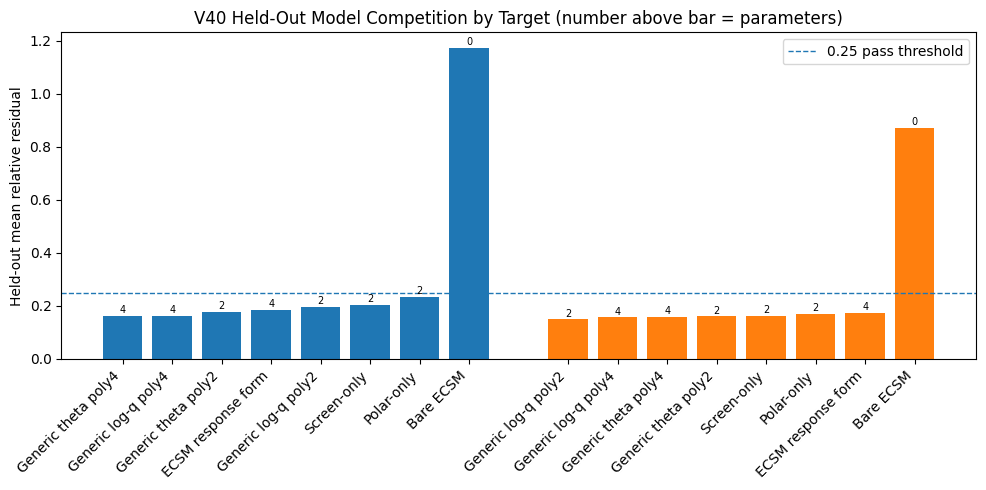

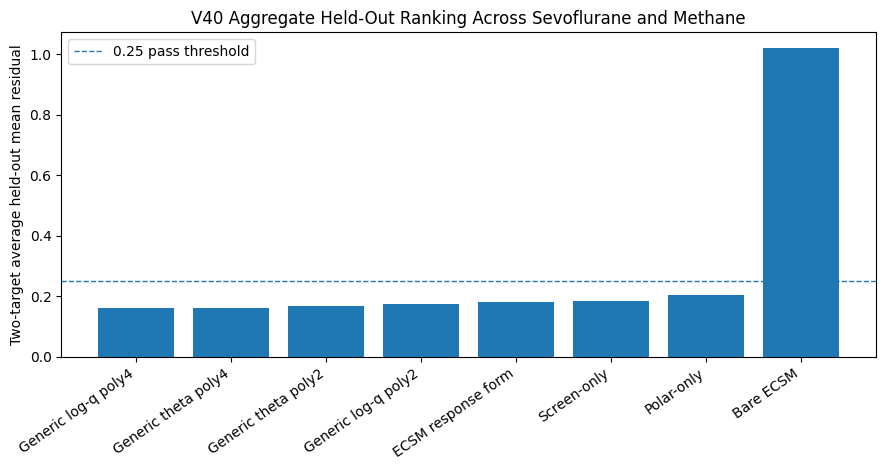

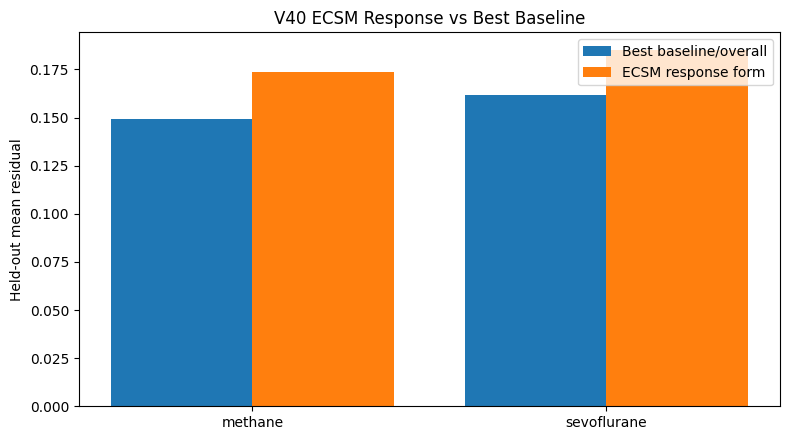

In [10]:
# Figures.

plt.figure(figsize=(10,5))
plot = test_results.copy()
tick_positions = []
tick_labels = []
offset = 0

for target in ["sevoflurane","methane"]:
    d = plot[plot.target==target].sort_values("mean")
    x = np.arange(len(d)) + offset
    plt.bar(x, d["mean"])

    for xi, (_, row) in zip(x, d.iterrows()):
        plt.text(xi, row["mean"]+0.01, str(row["n_params"]), ha="center", fontsize=7)

    tick_positions.extend(list(x))
    tick_labels.extend(list(d["model_label"]))
    offset += len(d) + 1

plt.axhline(0.25, linestyle="--", linewidth=1, label="0.25 pass threshold")
plt.xticks(tick_positions, tick_labels, rotation=45, ha="right")
plt.ylabel("Held-out mean relative residual")
plt.title("V40 Held-Out Model Competition by Target (number above bar = parameters)")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(9,4.8))
agg_test = aggregate_results[aggregate_results.split=="test"].sort_values("mean")
x = np.arange(len(agg_test))
plt.bar(x, agg_test["mean"])
plt.axhline(0.25, linestyle="--", linewidth=1, label="0.25 pass threshold")
plt.xticks(x, agg_test["model_label"], rotation=35, ha="right")
plt.ylabel("Two-target average held-out mean residual")
plt.title("V40 Aggregate Held-Out Ranking Across Sevoflurane and Methane")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4.5))
x = np.arange(len(best_comparison_df))
plt.bar(x-0.2, best_comparison_df["best_mean"], width=0.4, label="Best baseline/overall")
plt.bar(x+0.2, best_comparison_df["ecsm_mean"], width=0.4, label="ECSM response form")
plt.xticks(x, best_comparison_df["target"])
plt.ylabel("Held-out mean residual")
plt.title("V40 ECSM Response vs Best Baseline")
plt.legend()
plt.tight_layout()
plt.show()

## Cell 10 — Export outputs

In [11]:
# Export outputs and figures.

OUT = Path("ecsm_v40_model_competition_outputs")
OUT.mkdir(exist_ok=True)

sevo_df.to_csv(OUT/"v40_locked_sevoflurane_dataset.csv", index=False)
methane_df.to_csv(OUT/"v40_locked_methane_dataset.csv", index=False)
diag_all.to_csv(OUT/"v40_diagnostics_all_targets.csv", index=False)
results_df.to_csv(OUT/"v40_model_competition_results.csv", index=False)
test_results.sort_values(["target","mean"]).to_csv(OUT/"v40_heldout_test_ranking_by_target.csv", index=False)
aggregate_results.sort_values(["split","mean"]).to_csv(OUT/"v40_aggregate_results.csv", index=False)
best_comparison_df.to_csv(OUT/"v40_ecsm_vs_best_comparison.csv", index=False)
criteria_df.to_csv(OUT/"v40_criteria.csv", index=False)

with open(OUT/"v40_fits.json", "w") as f:
    json.dump(fits_store, f, indent=2)

with open(OUT/"run_summary_v40.json", "w") as f:
    json.dump(run_summary, f, indent=2)

# Save the three paper figures.
fig_files = []

plt.figure(figsize=(10,5))
plot = test_results.copy()
tick_positions = []
tick_labels = []
offset = 0
for target in ["sevoflurane","methane"]:
    d = plot[plot.target==target].sort_values("mean")
    x = np.arange(len(d)) + offset
    plt.bar(x, d["mean"])
    for xi, (_, row) in zip(x, d.iterrows()):
        plt.text(xi, row["mean"]+0.01, str(row["n_params"]), ha="center", fontsize=7)
    tick_positions.extend(list(x))
    tick_labels.extend(list(d["model_label"]))
    offset += len(d) + 1
plt.axhline(0.25, linestyle="--", linewidth=1, label="0.25 pass threshold")
plt.xticks(tick_positions, tick_labels, rotation=45, ha="right")
plt.ylabel("Held-out mean relative residual")
plt.title("V40 Held-Out Model Competition by Target")
plt.legend()
plt.tight_layout()
p = OUT/"fig_v40_heldout_model_competition_by_target.png"
plt.savefig(p, dpi=300, bbox_inches="tight")
plt.close()
fig_files.append(p)

plt.figure(figsize=(9,4.8))
agg_test = aggregate_results[aggregate_results.split=="test"].sort_values("mean")
x = np.arange(len(agg_test))
plt.bar(x, agg_test["mean"])
plt.axhline(0.25, linestyle="--", linewidth=1, label="0.25 pass threshold")
plt.xticks(x, agg_test["model_label"], rotation=35, ha="right")
plt.ylabel("Two-target average held-out mean residual")
plt.title("V40 Aggregate Held-Out Ranking Across Sevoflurane and Methane")
plt.legend()
plt.tight_layout()
p = OUT/"fig_v40_aggregate_heldout_ranking.png"
plt.savefig(p, dpi=300, bbox_inches="tight")
plt.close()
fig_files.append(p)

plt.figure(figsize=(8,4.5))
x = np.arange(len(best_comparison_df))
plt.bar(x-0.2, best_comparison_df["best_mean"], width=0.4, label="Best baseline/overall")
plt.bar(x+0.2, best_comparison_df["ecsm_mean"], width=0.4, label="ECSM response form")
plt.xticks(x, best_comparison_df["target"])
plt.ylabel("Held-out mean residual")
plt.title("V40 ECSM Response vs Best Baseline")
plt.legend()
plt.tight_layout()
p = OUT/"fig_v40_ecsm_vs_best_baseline.png"
plt.savefig(p, dpi=300, bbox_inches="tight")
plt.close()
fig_files.append(p)

zip_path = Path("ecsm_v40_model_competition_outputs.zip")
if zip_path.exists():
    zip_path.unlink()

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for item in OUT.iterdir():
        z.write(item, arcname=item.name)

print("Exported:", OUT)
print("ZIP:", zip_path)

Exported: ecsm_v40_model_competition_outputs
ZIP: ecsm_v40_model_competition_outputs.zip
